# **Feature Extraction**
## **Import Library and load dataset**


In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [94]:
data=pd.read_excel('/content/Data Preprocessing Data File.xlsx')

In [95]:
data.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,NaN,27.0,48000.0,Yes
2,Germany,NaN,54000.0,No
3,Spain,39.0,NaN,No
4,Germany,NaN,64000.0,Yes


In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     9 non-null      object 
 1   Age         8 non-null      float64
 2   Salary      8 non-null      float64
 3   Purchased   10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes


### **Data Preprocessing**

In [97]:
from sklearn.impute import SimpleImputer
lr=SimpleImputer(strategy='most_frequent')
data.iloc[:,0:1]=lr.fit_transform(data.iloc[:,0:1])

lr=SimpleImputer(strategy='mean')
data.iloc[:,1:2]=lr.fit_transform(data.iloc[:,1:2])

lr=SimpleImputer(strategy='mean')
data.iloc[:,2:3]=lr.fit_transform(data.iloc[:,2:3])

lr=SimpleImputer(strategy='most_frequent')
data.iloc[:,3:4]=lr.fit_transform(data.iloc[:,3:4])
data=data.iloc[:,:-1]


In [98]:
data

,Country,Age,Salary
0,France,44.000,72000.0
1,France,27.000,48000.0
2,Germany,39.875,54000.0
3,Spain,39.000,62250.0
4,Germany,39.875,64000.0
5,France,35.000,58000.0
6,Spain,39.000,52000.0
7,France,48.000,62250.0
8,Germany,50.000,83000.0
9,France,37.000,67000.0


### **Feature Transformation**

In [99]:
from sklearn.preprocessing import LabelEncoder
lr=LabelEncoder()
lr.fit_transform(data.iloc[:,0:1])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 1, 2, 1, 0, 2, 0, 1, 0])

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct=ColumnTransformer([('onehot',OneHotEncoder(),[0])], remainder='passthrough')
data=pd.DataFrame(ct.fit_transform(data))
data.columns= ['France','Germany','Spain','Age','Salary']

In [101]:
data

,France,Germany,Spain,Age,Salary
0,1.0,0.0,0.0,44.000,72000.0
1,1.0,0.0,0.0,27.000,48000.0
2,0.0,1.0,0.0,39.875,54000.0
3,0.0,0.0,1.0,39.000,62250.0
4,0.0,1.0,0.0,39.875,64000.0
5,1.0,0.0,0.0,35.000,58000.0
6,0.0,0.0,1.0,39.000,52000.0
7,1.0,0.0,0.0,48.000,62250.0
8,0.0,1.0,0.0,50.000,83000.0
9,1.0,0.0,0.0,37.000,67000.0


In [102]:
from sklearn.preprocessing import MinMaxScaler
lr=MinMaxScaler()
minmax=lr.fit_transform(data)

from sklearn.preprocessing import StandardScaler
lr=StandardScaler()
stdscalar=lr.fit_transform(data)

from sklearn.preprocessing import Normalizer
lr=Normalizer()
normaliser=lr.fit_transform(data)


### **Feature Scaling**

In [103]:
print(minmax)
print(stdscalar)
print(normaliser)

[[1.         0.         0.         0.73913043 0.68571429]
 [1.         0.         0.         0.         0.        ]
 [0.         1.         0.         0.55978261 0.17142857]
 [0.         0.         1.         0.52173913 0.40714286]
 [0.         1.         0.         0.55978261 0.45714286]
 [1.         0.         0.         0.34782609 0.28571429]
 [0.         0.         1.         0.52173913 0.11428571]
 [1.         0.         0.         0.91304348 0.40714286]
 [0.         1.         0.         1.         1.        ]
 [1.         0.         0.         0.43478261 0.54285714]]
[[ 1.         -0.65465367 -0.5         0.66491189  1.00270654]
 [ 1.         -0.65465367 -0.5        -2.07533106 -1.46549418]
 [-1.          1.52752523 -0.5         0.         -0.848444  ]
 [-1.         -0.65465367  2.         -0.14104192  0.        ]
 [-1.          1.52752523 -0.5         0.          0.17997297]
 [ 1.         -0.65465367 -0.5        -0.78580497 -0.43707721]
 [-1.         -0.65465367  2.         -0.

### **Feature Selection**

In [104]:
corr=data.corr()


<Axes: >

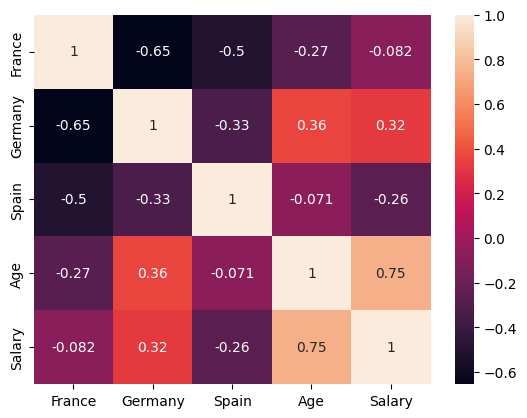

In [105]:
sns.heatmap(corr, annot=True)